# Phase 3 - Confidence Intervals and Sensitivity Analysis

Notebook báo cáo CI cho trung bình G3 và bốn contrast được xác định rõ: `M-F`, `U-R`, `higher yes-no`, `failures 0->0`. Power hậu nghiệm dựa trên effect quan sát được thay bằng minimum detectable effect (MDE) ở power 80%.

## 0. Setup và dữ liệu

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
ALPHA = 0.05
ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_OUT = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "report" / "figures"
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.max_columns", 50)

def display_table(data, caption=None, precision=3):
    """Hiển thị DataFrame với đường viền rõ, dùng được trực tiếp trong Jupyter."""
    if isinstance(data, pd.Series):
        data = data.rename("value").to_frame()
    styler = (
        data.style
        .format(precision=precision, na_rep="-")
        .set_caption(caption or "")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
            {"selector": "th", "props": [("border", "1px solid #777"), ("padding", "6px"),
                                           ("background-color", "#e9eef5"), ("text-align", "center")]},
            {"selector": "td", "props": [("border", "1px solid #999"), ("padding", "6px")]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                                ("font-size", "1.05em"), ("padding", "6px")]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f7f9fc")]},
        ])
    )
    display(styler)

print(f"Project root: {ROOT}")
from statsmodels.stats.power import TTestIndPower, FTestAnovaPower

N_BOOTSTRAP = 5000
df = pd.read_csv(DATA_OUT / "student_mat_clean.csv")
assert len(df) == 395
print(f"Shape: {df.shape}")

Project root: C:\Users\LENOVO\Downloads\khu lap trinh\student-performance-project
Shape: (395, 33)


## 1. Hàm CI và effect size

In [2]:
def bootstrap_ci(data, stat_fn=np.mean, n_boot=N_BOOTSTRAP, ci=.95, method="percentile", seed=RANDOM_SEED):
    data = np.asarray(data, float); rng = np.random.default_rng(seed); n = len(data)
    point = stat_fn(data)
    boot = np.array([stat_fn(data[rng.integers(0, n, n)]) for _ in range(n_boot)])
    alpha = 1 - ci
    if method == "percentile":
        lo, hi = np.quantile(boot, [alpha / 2, 1 - alpha / 2])
    elif method == "bca":
        prop = np.clip(np.mean(boot < point), 1e-9, 1 - 1e-9)
        z0 = stats.norm.ppf(prop)
        jack = np.array([stat_fn(np.delete(data, i)) for i in range(n)])
        delta = jack.mean() - jack
        acceleration = np.sum(delta**3) / (6 * np.sum(delta**2)**1.5) if np.sum(delta**2) else 0
        z = stats.norm.ppf([alpha / 2, 1 - alpha / 2])
        adjusted = stats.norm.cdf(z0 + (z0 + z) / (1 - acceleration * (z0 + z)))
        lo, hi = np.quantile(boot, adjusted)
    else:
        raise ValueError("method must be percentile or bca")
    return point, lo, hi, boot

def t_ci_mean(x, conf=.95):
    x = np.asarray(x, float); mean = x.mean(); se = stats.sem(x)
    lo, hi = stats.t.interval(conf, len(x) - 1, loc=mean, scale=se)
    return mean, lo, hi

def hedges_g(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float); nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return ((x.mean() - y.mean()) / pooled) * (1 - 3 / (4 * (nx + ny) - 9))

def welch_diff_ci(x, y, conf=.95):
    x, y = np.asarray(x, float), np.asarray(y, float); nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1); diff = x.mean() - y.mean()
    se = np.sqrt(vx / nx + vy / ny)
    dof = (vx / nx + vy / ny)**2 / ((vx / nx)**2 / (nx - 1) + (vy / ny)**2 / (ny - 1))
    lo, hi = stats.t.interval(conf, dof, loc=diff, scale=se)
    return diff, lo, hi

def bootstrap_two_group(x, y, stat_fn, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    x, y = np.asarray(x, float), np.asarray(y, float); rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        sx = x[rng.integers(0, len(x), len(x))]; sy = y[rng.integers(0, len(y), len(y))]
        boot[i] = stat_fn(sx, sy)
    return stat_fn(x, y), *np.quantile(boot, [.025, .975])

## 2. CI cho trung bình và trung vị G3

,quantity,group,method,point_estimate,ci_lower,ci_upper,n
0,mean_G3,all,t,10.41519,9.961992,10.868388,395
1,mean_G3,all,bootstrap_percentile,10.41519,9.974684,10.858291,395
2,mean_G3,all,bootstrap_bca,10.41519,9.964557,10.848101,395
3,median_G3,all,bootstrap_percentile,11.00000,10.000000,11.000000,395


'CI cho trung bình và trung vị G3'

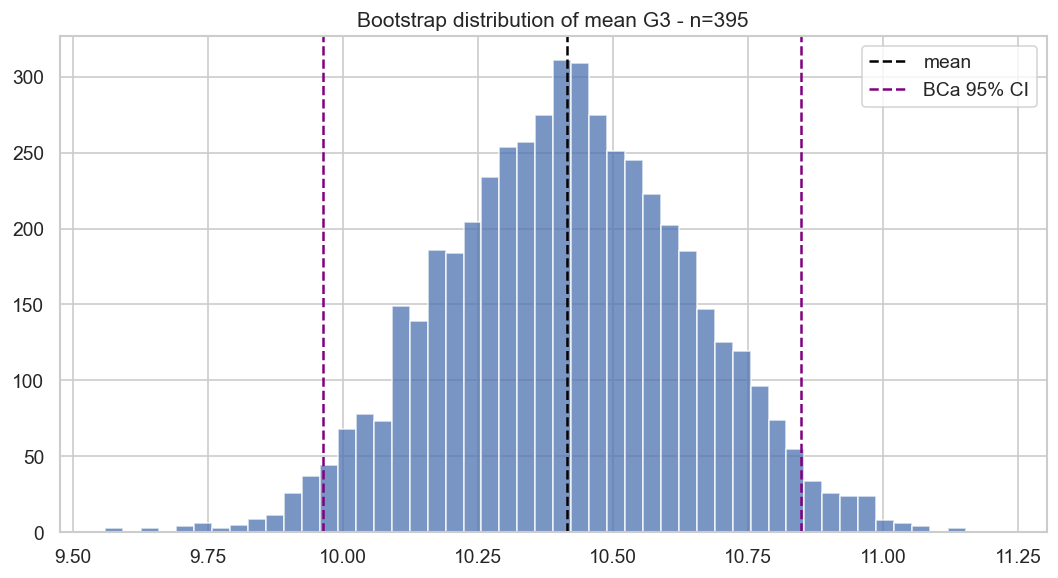

In [3]:
records = []
mean_t = t_ci_mean(df["G3"])
mean_pct = bootstrap_ci(df["G3"], np.mean, method="percentile")
mean_bca = bootstrap_ci(df["G3"], np.mean, method="bca")
median_pct = bootstrap_ci(df["G3"], np.median, method="percentile")
for quantity, method, values in [
    ("mean_G3", "t", mean_t), ("mean_G3", "bootstrap_percentile", mean_pct[:3]),
    ("mean_G3", "bootstrap_bca", mean_bca[:3]), ("median_G3", "bootstrap_percentile", median_pct[:3]),
]:
    records.append({"quantity": quantity, "group": "all", "method": method,
                    "point_estimate": values[0], "ci_lower": values[1], "ci_upper": values[2], "n": len(df)})
display(pd.DataFrame(records), "CI cho trung bình và trung vị G3", precision=4)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(mean_pct[3], bins=50, color="#4C72B0", alpha=.75)
for value, color, label in [(mean_t[0], "black", "mean"), (mean_bca[1], "purple", "BCa 95% CI"),
                            (mean_bca[2], "purple", None)]:
    ax.axvline(value, color=color, ls="--", label=label)
ax.legend(); ax.set_title("Bootstrap distribution of mean G3 - n=395")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "ci_bootstrap_mean_g3.png"); plt.show()

## 3. CI cho các contrast được định nghĩa trước

,comparison,n1,n2,diff_mean,welch_lo,welch_hi,boot_lo,boot_hi,hedges_g,g_lo,g_hi
0,sex (M - F),187,208,0.948092,0.045452,1.850732,0.041023,1.845071,0.207397,0.008967,0.409629
1,address (U - R),307,88,1.162903,0.073404,2.252403,0.103410,2.225189,0.254450,0.023827,0.493116
2,higher (yes - no),375,20,3.808000,1.509446,6.106554,1.813333,5.940133,0.842685,0.400957,1.328670
3,failures (0 - >0),312,83,3.988145,2.862454,5.113836,2.915153,5.090533,0.928225,0.669682,1.209499


'CI cho các contrast định nghĩa trước'

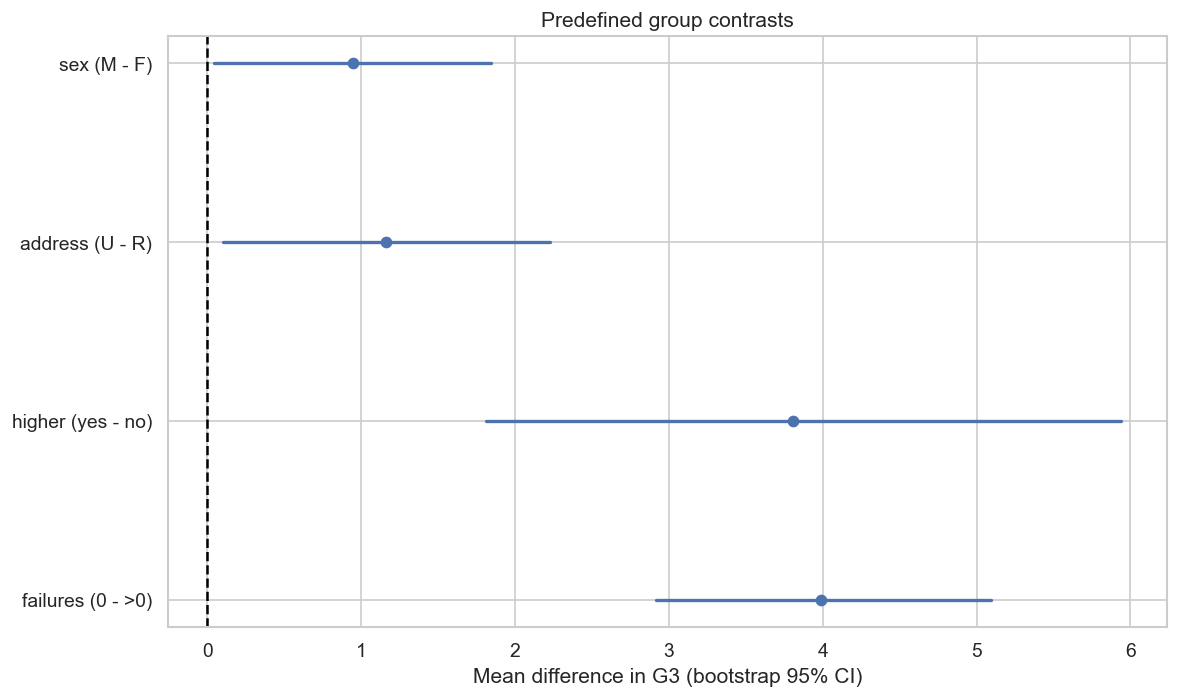

In [4]:
contrasts = [
    ("sex (M - F)", df.loc[df.sex == "M", "G3"], df.loc[df.sex == "F", "G3"]),
    ("address (U - R)", df.loc[df.address == "U", "G3"], df.loc[df.address == "R", "G3"]),
    ("higher (yes - no)", df.loc[df.higher == "yes", "G3"], df.loc[df.higher == "no", "G3"]),
    ("failures (0 - >0)", df.loc[df.failures == 0, "G3"], df.loc[df.failures > 0, "G3"]),
]
contrast_rows = []
for label, x, y in contrasts:
    w = welch_diff_ci(x, y)
    b = bootstrap_two_group(x, y, lambda a, b: a.mean() - b.mean())
    g = bootstrap_two_group(x, y, hedges_g)
    contrast_rows.append({"comparison": label, "n1": len(x), "n2": len(y), "diff_mean": w[0],
                          "welch_lo": w[1], "welch_hi": w[2], "boot_lo": b[1], "boot_hi": b[2],
                          "hedges_g": g[0], "g_lo": g[1], "g_hi": g[2]})
    records.extend([
        {"quantity": "diff_mean_G3", "group": label, "method": "welch", "point_estimate": w[0],
         "ci_lower": w[1], "ci_upper": w[2], "n": len(x) + len(y)},
        {"quantity": "diff_mean_G3", "group": label, "method": "bootstrap_percentile", "point_estimate": b[0],
         "ci_lower": b[1], "ci_upper": b[2], "n": len(x) + len(y)},
        {"quantity": "hedges_g", "group": label, "method": "bootstrap_percentile", "point_estimate": g[0],
         "ci_lower": g[1], "ci_upper": g[2], "n": len(x) + len(y)},
    ])
contrast_table = pd.DataFrame(contrast_rows)
display(contrast_table, "CI cho các contrast định nghĩa trước", precision=4)

fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(contrast_table))[::-1]
for y, (_, row) in zip(ypos, contrast_table.iterrows()):
    ax.plot([row.boot_lo, row.boot_hi], [y, y], lw=2, color="#4C72B0")
    ax.plot(row.diff_mean, y, "o", color="#4C72B0")
ax.axvline(0, color="black", ls="--"); ax.set_yticks(ypos); ax.set_yticklabels(contrast_table.comparison)
ax.set_xlabel("Mean difference in G3 (bootstrap 95% CI)"); ax.set_title("Predefined group contrasts")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "ci_group_differences.png"); plt.show()

## 4. Sensitivity analysis cho quyết định dữ liệu

In [5]:
sensitivity = []
for label, sample in [("all G3 values", df), ("conditional G3>0", df[df.G3 > 0])]:
    point, lo, hi, _ = bootstrap_ci(sample["G3"], np.mean, method="bca")
    rho, p = stats.spearmanr(sample["absences"], sample["G3"])
    sensitivity.append({"sample": label, "n": len(sample), "mean_G3": point, "mean_bca_lo": lo,
                        "mean_bca_hi": hi, "rho_absences_G3": rho, "p_absences_G3": p})
display(pd.DataFrame(sensitivity), "Sensitivity analysis cho quyết định dữ liệu", precision=4)

,sample,n,mean_G3,mean_bca_lo,mean_bca_hi,rho_absences_G3,p_absences_G3
0,all G3 values,395,10.41519,9.964557,10.848101,0.017731,0.725363
1,conditional G3>0,357,11.52381,11.192786,11.853364,-0.244197,0.000003


'Sensitivity analysis cho quyết định dữ liệu'

## 5. Sensitivity power: minimum detectable effect

,comparison,n1,n2,MDE_d_at_80pct_power
0,sex (M - F),187,208,[0.28301727280828604]
1,address (U - R),307,88,0.33959
2,higher (yes - no),375,20,0.644518
3,failures (0 - >0),312,83,0.346857


'Minimum detectable effect tại power 80%'

ANOVA sensitivity for failures (4 groups, balanced approximation): MDE Cohen f=0.167
Lưu ý: phép tính ANOVA là xấp xỉ vì nhóm failures mất cân bằng và Phase 2 dùng Kruskal-Wallis.


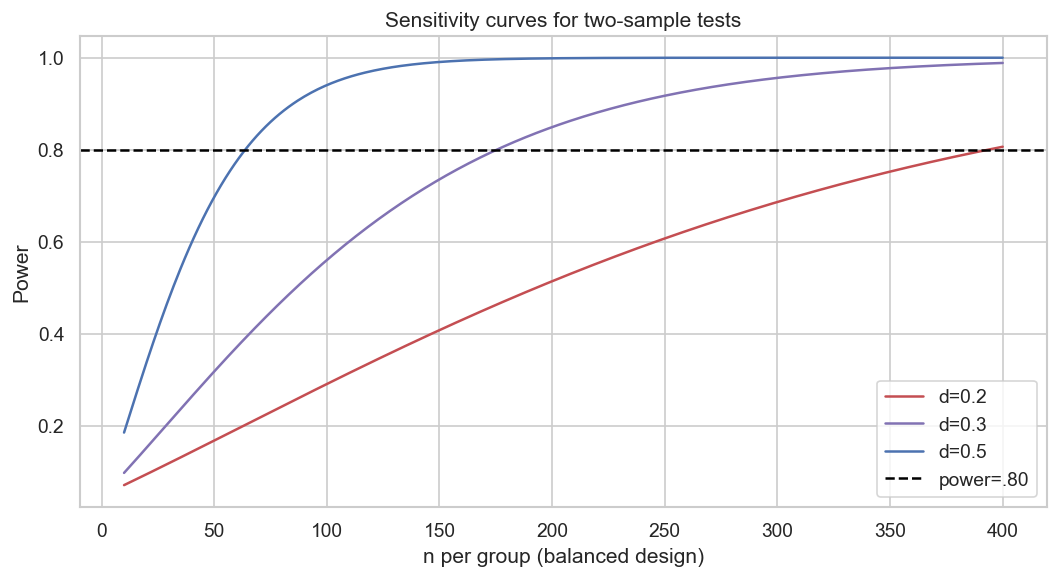

In [8]:
tt_power = TTestIndPower()
mde_rows = []
for label, x, y in contrasts:
    ratio = len(y) / len(x)
    mde = tt_power.solve_power(effect_size=None, nobs1=len(x), alpha=ALPHA, power=.80,
                               ratio=ratio, alternative="two-sided")
    mde_rows.append({"comparison": label, "n1": len(x), "n2": len(y), "MDE_d_at_80pct_power": mde})
mde_table = pd.DataFrame(mde_rows)
display(mde_table, "Minimum detectable effect tại power 80%", precision=4)

anova_power = FTestAnovaPower()
anova_mde = anova_power.solve_power(effect_size=None, nobs=len(df), alpha=ALPHA, power=.80, k_groups=4)
print(f"ANOVA sensitivity for failures (4 groups, balanced approximation): MDE Cohen f={anova_mde:.3f}")
print("Lưu ý: phép tính ANOVA là xấp xỉ vì nhóm failures mất cân bằng và Phase 2 dùng Kruskal-Wallis.")

n_range = np.arange(10, 401)
fig, ax = plt.subplots(figsize=(9, 5))
for d, color in zip([.2, .3, .5], ["#C44E52", "#8172B3", "#4C72B0"]):
    ax.plot(n_range, tt_power.power(d, n_range, ALPHA, ratio=1), label=f"d={d}", color=color)
ax.axhline(.8, color="black", ls="--", label="power=.80")
ax.set_xlabel("n per group (balanced design)"); ax.set_ylabel("Power"); ax.legend()
ax.set_title("Sensitivity curves for two-sample tests")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "ci_power_curve.png"); plt.show()

## 6. Xuất kết quả

In [7]:
ci_results = pd.DataFrame(records)
ci_results["conf_level"] = .95
ci_results = ci_results[["quantity", "group", "method", "point_estimate", "ci_lower", "ci_upper", "conf_level", "n"]]
with (DATA_OUT / "bootstrap_ci_results.csv").open("w", encoding="utf-8", newline="") as handle:
    ci_results.to_csv(handle, index=False, lineterminator=chr(10))
with (DATA_OUT / "power_sensitivity_results.csv").open("w", encoding="utf-8", newline="") as handle:
    mde_table.to_csv(handle, index=False, lineterminator=chr(10))
print(f"Đã xuất {len(ci_results)} dòng CI và {len(mde_table)} dòng sensitivity power.")

Đã xuất 16 dòng CI và 4 dòng sensitivity power.


## Kết luận Phase 3

- CI được báo cáo cho toàn bộ mẫu 395 quan sát và cho bốn contrast định nghĩa trước.
- Các CI 95% của contrast là khoảng riêng lẻ, chưa phải simultaneous CI; kết luận xác nhận nhiều giả thuyết vẫn dựa trên Holm correction ở Phase 2.
- CI diễn tả độ bất định của ước lượng; không loại bỏ confounding hoặc giới hạn khả năng khái quát hóa.
- So sánh `G3>0` chỉ là sensitivity analysis, cho thấy hậu quả của việc loại điểm 0.
- MDE ở power 80% thay cho observed power, tránh diễn giải vòng tròn từ effect size quan sát và p-value.
- CI bootstrap vẫn giả định các quan sát đủ độc lập; cấu trúc học sinh nằm trong hai trường là một giới hạn của dữ liệu.